In [3]:
import pandas as pd
import os
import sys

# Ensure the correct directory paths
init_dir = os.getcwd()
parent_dir = os.path.dirname(init_dir)
mlc_dir = os.path.join(init_dir, "mlc")
sys.path.append(mlc_dir)
# Install the cashflow module if not found
try:
	import cashflow
except ModuleNotFoundError:
	print("Module 'cashflow' not found. Please ensure it exists in the directory:", mlc_dir)

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df_consumers = pd.read_parquet(parent_dir+"/cashflow-data/consumer_data.parquet")
df_transactions = pd.read_parquet(parent_dir+"/cashflow-data/transactions.parquet")

In [6]:
merged_df = df_transactions.merge(df_consumers, on = "masked_consumer_id")
filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]

In [7]:
filtered_df["loan_type"] = filtered_df["masked_consumer_id"].str[2]
filtered_df["loan_type"] = filtered_df["loan_type"].astype(int)

C:\Users\18585\AppData\Local\Temp\ipykernel_19376\4155308201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["loan_type"] = filtered_df["masked_consumer_id"].str[2]
C:\Users\18585\AppData\Local\Temp\ipykernel_19376\4155308201.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["loan_type"] = filtered_df["loan_type"].astype(int)


In [8]:
filtered_df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date,FPF_TARGET,total_balance,loan_type
0,C02103629,2022-08-12,-21.00,27.0,C02T02715977,2022-11-16,1.0,109.53,2
1,C02103629,2022-08-09,-8.60,22.0,C02T02715978,2022-11-16,1.0,109.53,2
2,C02103629,2022-08-07,-30.05,16.0,C02T02715979,2022-11-16,1.0,109.53,2
3,C02103629,2022-09-29,-0.46,0.0,C02T02715980,2022-11-16,1.0,109.53,2
4,C02103629,2022-07-21,-50.00,12.0,C02T02715981,2022-11-16,1.0,109.53,2
...,...,...,...,...,...,...,...,...,...
17737465,C04100783,2022-03-29,-11.20,14.0,C04T01071462,2022-03-31,0.0,1104.86,4
17737466,C04100783,2022-03-29,-1.00,1.0,C04T01071463,2022-03-31,0.0,1104.86,4
17737467,C04100783,2022-03-30,-2.00,1.0,C04T01071464,2022-03-31,0.0,1104.86,4
17737468,C04100783,2022-03-30,-15.00,17.0,C04T01071465,2022-03-31,0.0,1104.86,4


In [9]:
trans_cats = pd.read_csv(parent_dir+"/transaction_categories.csv")
trans_cats

,code,description
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


In [10]:
cats_to_codes = dict(zip(trans_cats["description"], trans_cats["code"]))
codes_to_cats = dict(zip(trans_cats["code"], trans_cats["description"]))

dataframes_by_loans is a dictionary. Keys of which correspond to loan type, mapping to the merged dataframe that contains transactions and evaluation data.

In [11]:
dataframes_by_loans = {lt: pd.DataFrame() for lt in filtered_df.loan_type.unique()}
for key in dataframes_by_loans:
    dataframes_by_loans[key] = filtered_df[:][filtered_df.loan_type == key].drop(columns = ["loan_type","masked_transaction_id"])

co2_df = dataframes_by_loans[2]
co2_df["masked_consumer_id"] = co2_df["masked_consumer_id"].str[-4:]
co2_df["evaluation_date"] = pd.to_datetime(co2_df["evaluation_date"])
co2_df["posted_date"] = pd.to_datetime(co2_df["posted_date"])

In [12]:
# nested_df = (
#     co2_df
#     .groupby(['masked_consumer_id', 'FPF_TARGET', 'evaluation_date',"total_balance"])
#     .apply(lambda x: x.drop(columns=['masked_consumer_id', 'FPF_TARGET', 'evaluation_date',"total_balance"]).to_dict(orient='records'))
#     .reset_index()
#     .rename(columns={0: 'nested'})
# )
# nested_df["evaluation_date"] = pd.to_datetime(nested_df["evaluation_date"])
# nested_df

In [13]:
co2_df = co2_df[abs(co2_df["amount"])>5]

In [14]:
seasonal_cats = [3,9,11,12,13,17,26,29,31,32,34]

In [15]:
ids_by_transactions = {}
for i in range(36):
    ids_by_transactions[i] = co2_df[co2_df["category"] == i][["masked_consumer_id","FPF_TARGET", "posted_date","amount"]]

In [16]:
co2_df

,masked_consumer_id,posted_date,amount,category,evaluation_date,FPF_TARGET,total_balance
0,3629,2022-08-12,-21.00,27.0,2022-11-16,1.0,109.53
1,3629,2022-08-09,-8.60,22.0,2022-11-16,1.0,109.53
2,3629,2022-08-07,-30.05,16.0,2022-11-16,1.0,109.53
4,3629,2022-07-21,-50.00,12.0,2022-11-16,1.0,109.53
7,3629,2022-10-06,-15.33,1.0,2022-11-16,1.0,109.53
...,...,...,...,...,...,...,...
6648184,1789,2022-08-30,-14.73,16.0,2022-10-31,1.0,0.00
6648185,1789,2022-10-18,-18.71,14.0,2022-10-31,1.0,0.00
6648186,1789,2022-06-30,-5.07,16.0,2022-10-31,1.0,0.00
6648187,1789,2022-08-30,-10.23,16.0,2022-10-31,1.0,0.00


In [83]:
def plot_cat(code):
    transactions = ids_by_transactions.get(code, pd.DataFrame())
    vol_dfs = {}
    avg_std_by_day = {}
    avg_amt_by_day = {}
    for target in range(2):
        transactions_target = transactions[transactions["FPF_TARGET"] == target].copy()
        transactions_target["posted_date"] = pd.to_datetime(transactions_target["posted_date"], errors='coerce')
        transactions_target = transactions_target.dropna(subset=["posted_date", "amount"])

        transactions_target["day_of_month"] = transactions_target["posted_date"].dt.day

        # -------------------------
        # 1. Inter-Transaction Volatility
        # -------------------------
        inter_tx_volatility = []

        for cust_id, group in transactions_target.groupby("masked_consumer_id"):
            group = group.sort_values("posted_date")
            time_deltas = group["posted_date"].diff().dropna().dt.total_seconds() / (3600 * 24)  # in days
            if len(time_deltas) > 1:
                inter_tx_vol = np.std(time_deltas)
                inter_tx_volatility.append({"masked_consumer_id": cust_id, "inter_tx_volatility": inter_tx_vol})

        inter_tx_df = pd.DataFrame(inter_tx_volatility)

        # -------------------------
        # 2. Transaction Count Volatility
        # -------------------------
        tx_count_volatility = []

        for cust_id, group in transactions_target.groupby("masked_consumer_id"):
            tx_counts = group.groupby(group["posted_date"].dt.date).size()  # Count per date
            if len(tx_counts) > 1:
                count_vol = np.std(tx_counts)
                tx_count_volatility.append({"masked_consumer_id": cust_id, "tx_count_volatility": count_vol})

        tx_count_df = pd.DataFrame(tx_count_volatility)

        # -------------------------
        # Merge and Inspect
        # -------------------------
        combined_df = pd.merge(inter_tx_df, tx_count_df, on="masked_consumer_id", how="outer")
        print(f"\nTarget = {target}")
        print(combined_df.describe())
        vol_dfs[target] = combined_df
        # -------------------------
        # Scatter Plot (Amount vs Day of Month)
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.scatter(transactions_target["day_of_month"], transactions_target["amount"], alpha=0.5)
        plt.xlabel("Day of Month")
        plt.ylabel("Transaction Amount")
        plt.title(f"Scatter: Target = {target} for {codes_to_cats.get(code, code)}")
        plt.show()

        # -------------------------
        # Histogram of Day of Month
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.hist(transactions_target["day_of_month"], bins=30, color='skyblue', edgecolor='black')
        plt.xlabel("Day of Month")
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {codes_to_cats.get(code, code)} by DoM for Target {target}")
        plt.show()

        # -------------------------
        # Std Dev of Amount per Consumer per Day
        # -------------------------
        std_per_consumer = (
            transactions_target.groupby(["masked_consumer_id", "day_of_month"])["amount"]
            .std()
            .reset_index(name="std_amount")
        )
        # Compute average amount per consumer
        avg_amount_per_consumer = (
            transactions_target.groupby("masked_consumer_id")["amount"]
            .mean()
            .rename("avg_amount")
            .reset_index()
        )

        # Merge with std dev dataframe
        std_per_consumer = std_per_consumer.merge(avg_amount_per_consumer, on="masked_consumer_id")

        avg_std_by_day[target] = std_per_consumer.groupby("day_of_month")["std_amount"].mean()
        avg_amt_by_day[target] = std_per_consumer.groupby("day_of_month")["avg_amount"].mean()
        plt.figure(figsize=(10, 6))
        plt.plot(avg_std_by_day[target].index, avg_std_by_day[target].values, marker='o', color='orange')
        plt.xlabel("Day of Month")
        plt.ylabel("Avg Std Dev of Amounts")
        plt.title(f"Avg Amount Std Dev per DoM for Target = {target} in {codes_to_cats.get(code, code)}")
        plt.show()
    return vol_dfs, avg_amt_by_day



Target = 0
       inter_tx_volatility  tx_count_volatility
count           135.000000           161.000000
mean             10.462059             0.059348
std              10.481804             0.146589
min               0.000000             0.000000
25%               3.003330             0.000000
50%               8.041559             0.000000
75%              13.492920             0.000000
max              58.500000             0.500000


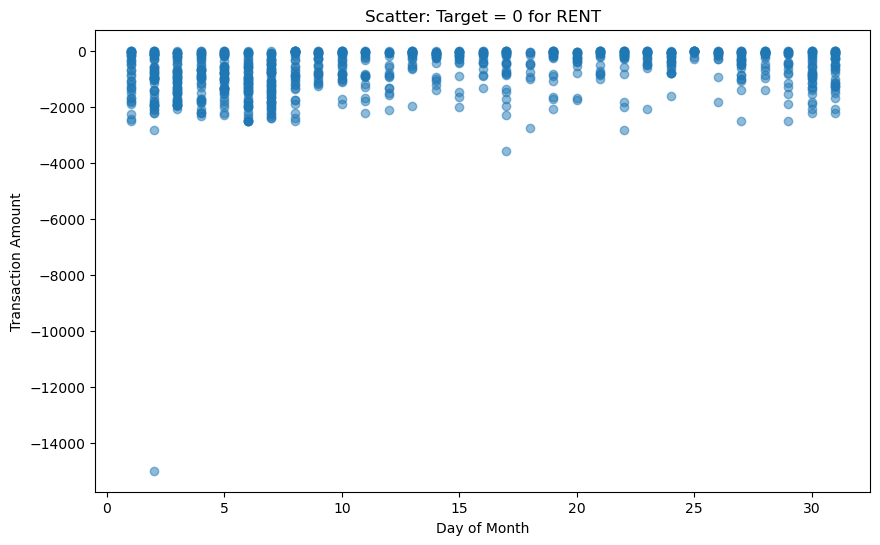

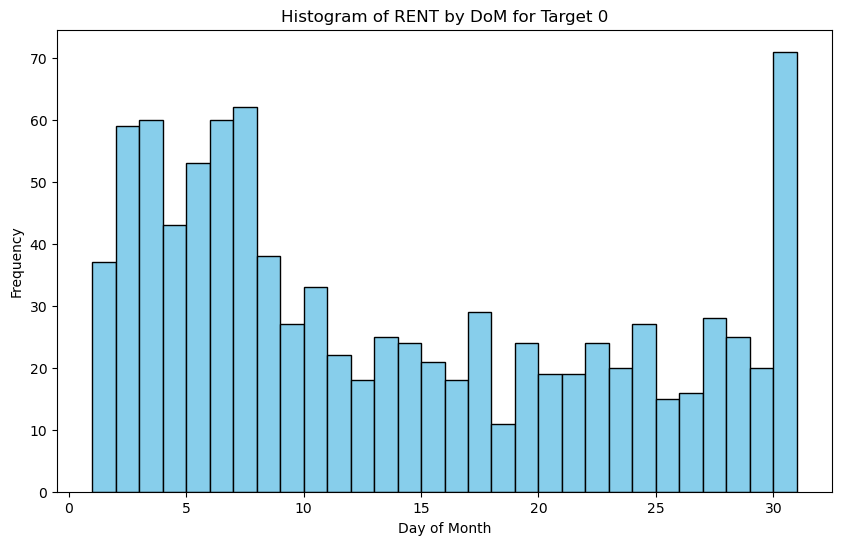

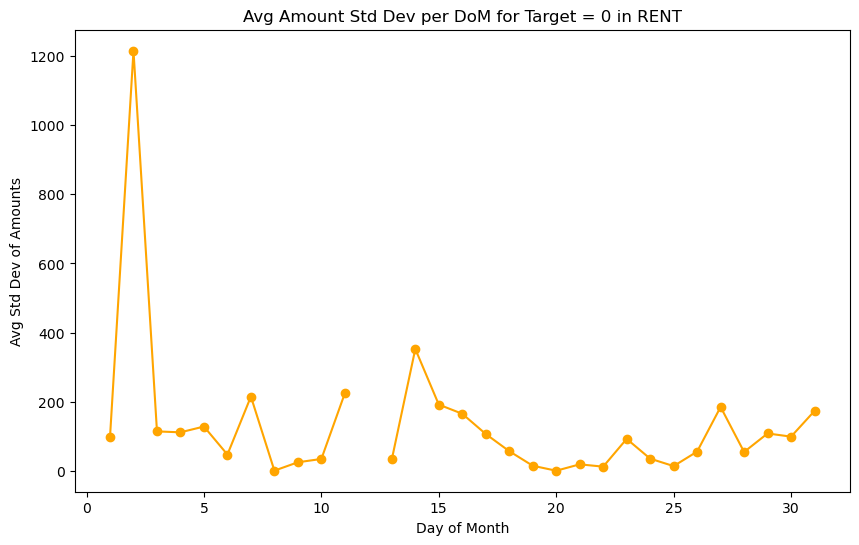


Target = 1
       inter_tx_volatility  tx_count_volatility
count           107.000000           134.000000
mean             10.300287             0.042779
std               9.906097             0.129092
min               0.000000             0.000000
25%               3.520378             0.000000
50%               7.984986             0.000000
75%              13.304885             0.000000
max              52.500000             0.631961


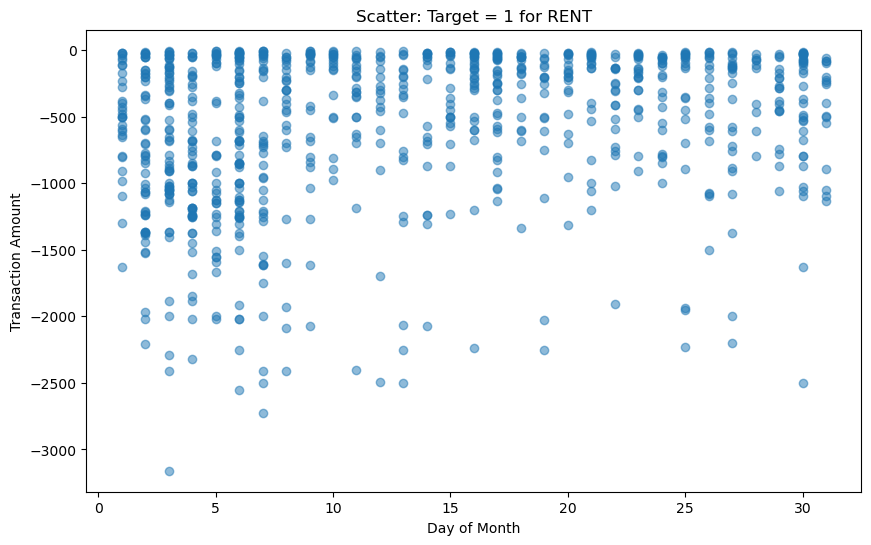

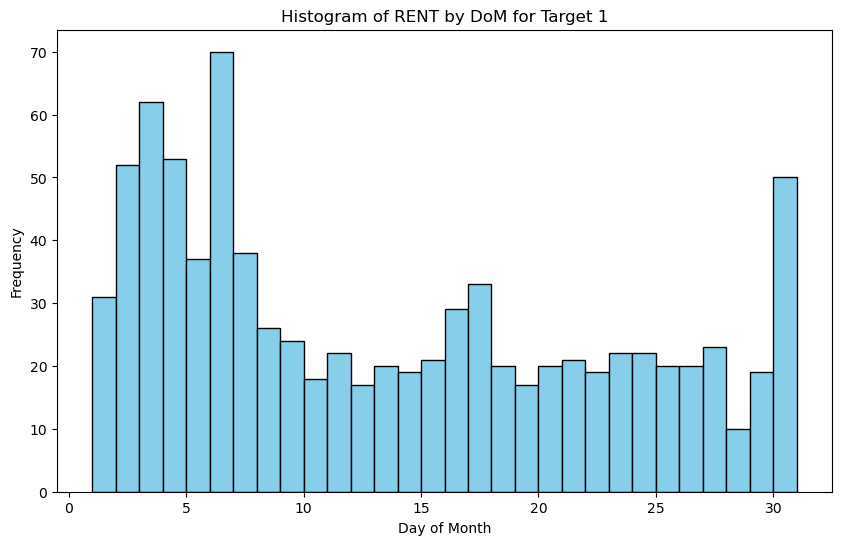

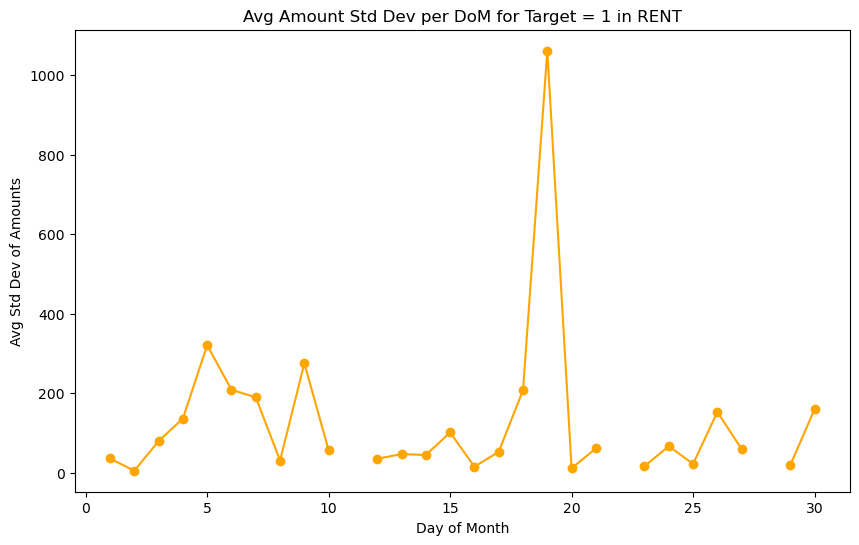

Target = 0
    masked_consumer_id  inter_tx_volatility  tx_count_volatility
0                 0005            12.710272             0.349927
1                 0063             1.500000             0.000000
2                 0121             9.513149             0.000000
3                 0151             3.500000             0.000000
4                 0212            10.657548             0.000000
..                 ...                  ...                  ...
159               4249                  NaN             0.000000
160               4509                  NaN             0.000000
161               4583                  NaN             0.000000
162               4949                  NaN             0.000000
163               4980                  NaN             0.000000

[164 rows x 3 columns]
day_of_month
1     -761.976332
2    -1002.318829
3     -950.366128
4     -842.488735
5     -939.247371
6    -1072.628197
7     -928.344297
8     -732.628834
9     -558.054730
10    -542

In [84]:
vol_rent, avg_rent_amt = plot_cat(cats_to_codes["RENT"])
for i in range(2):
    print(f"Target = {i}")
    print(vol_rent[i])
    print(avg_rent_amt[i])

In [19]:
co2_df[(co2_df["category"]==0.0) & (abs(co2_df["amount"])<2)]["amount"]

Series([], Name: amount, dtype: float64)

Aggregating weekly data, Weekday/Weekend classification

In [20]:
co2_df["day_type"] = co2_df["posted_date"].dt.dayofweek
co2_day = co2_df[abs(co2_df["amount"])>5].drop(columns=["posted_date"]).copy()
co2_day

C:\Users\18585\AppData\Local\Temp\ipykernel_19376\2647576327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2_df["day_type"] = co2_df["posted_date"].dt.dayofweek


,masked_consumer_id,amount,category,evaluation_date,FPF_TARGET,total_balance,day_type
0,3629,-21.00,27.0,2022-11-16,1.0,109.53,4
1,3629,-8.60,22.0,2022-11-16,1.0,109.53,1
2,3629,-30.05,16.0,2022-11-16,1.0,109.53,6
4,3629,-50.00,12.0,2022-11-16,1.0,109.53,3
7,3629,-15.33,1.0,2022-11-16,1.0,109.53,3
...,...,...,...,...,...,...,...
6648184,1789,-14.73,16.0,2022-10-31,1.0,0.00,1
6648185,1789,-18.71,14.0,2022-10-31,1.0,0.00,1
6648186,1789,-5.07,16.0,2022-10-31,1.0,0.00,3
6648187,1789,-10.23,16.0,2022-10-31,1.0,0.00,1


In [21]:
transactions_by_cat_day = {}
for i in range(36):
    transactions_by_cat_day[i] = co2_day[co2_day["category"] == i][["masked_consumer_id","FPF_TARGET", "amount","total_balance","day_type"]]

In [61]:
def plot_cat_week(code):
    transactions = transactions_by_cat_day.get(code, pd.DataFrame())
    avg_std_by_day = {}
    avg_amt_by_day = {}
    for target in range(2):
        transactions_target = transactions[transactions["FPF_TARGET"] == target].copy()
        transactions_target = transactions_target.dropna(subset=["amount"])
        # -------------------------
        # Scatter Plot (Amount vs Day of Week)
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.scatter(transactions_target["day_type"], transactions_target["amount"], alpha=0.5)
        plt.xlabel("Day of Week")
        plt.ylabel("Transaction Amount")
        plt.title(f"Scatter: Target = {target} for {codes_to_cats.get(code, code)}")
        plt.show()

        # -------------------------
        # Histogram of Day of Week
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.hist(transactions_target["day_type"], bins=30, color='skyblue', edgecolor='black')
        plt.xlabel("Day of Week")
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {codes_to_cats.get(code, code)} by DoM for Target {target}")
        plt.show()

        # -------------------------
        # Std Dev of Amount per Consumer per Day
        # -------------------------
        std_per_consumer = (
            transactions_target.groupby(["masked_consumer_id", "day_type"])["amount"]
            .std()
            .reset_index(name="std_amount")
        )
        # Compute average amount per consumer
        avg_amt = (
        transactions_target.groupby(["masked_consumer_id", "day_type"])["amount"]
        .mean()
        .reset_index(name="avg_amount")
    )

        # Merge with std dev dataframe
        std_per_consumer = std_per_consumer.merge(avg_amt, on=["masked_consumer_id", "day_type"])

        avg_std_by_day[target] = std_per_consumer.groupby("day_type")["std_amount"].mean()
        avg_amt_by_day[target] = std_per_consumer.groupby("day_type")["avg_amount"].mean()
        plt.figure(figsize=(10, 6))
        plt.plot(avg_std_by_day[target].index, avg_std_by_day[target].values, marker='o', color='orange')
        plt.xlabel("Day of Week")
        plt.ylabel("Avg Std Dev of Amounts")
        plt.title(f"Avg Amount Std Dev per DoM for Target = {target} in {codes_to_cats.get(code, code)}")
        plt.show()
    return avg_std_by_day, avg_amt_by_day

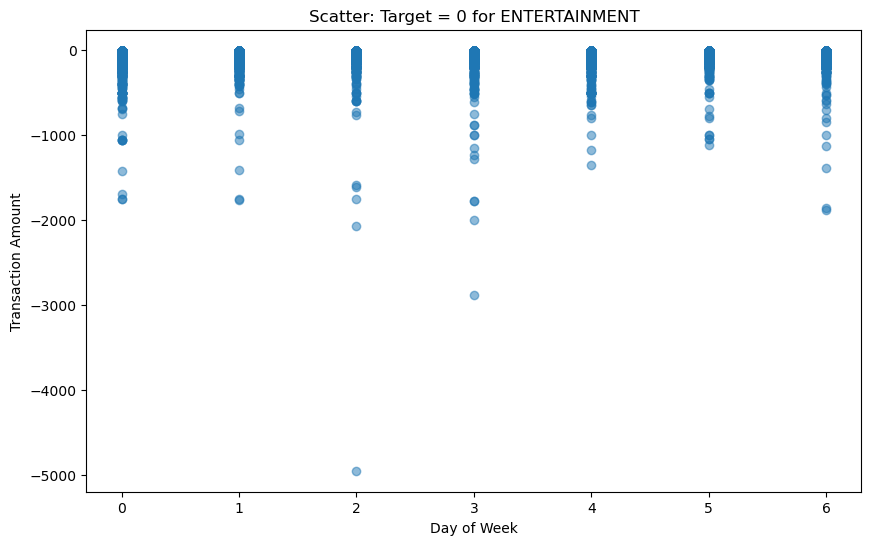

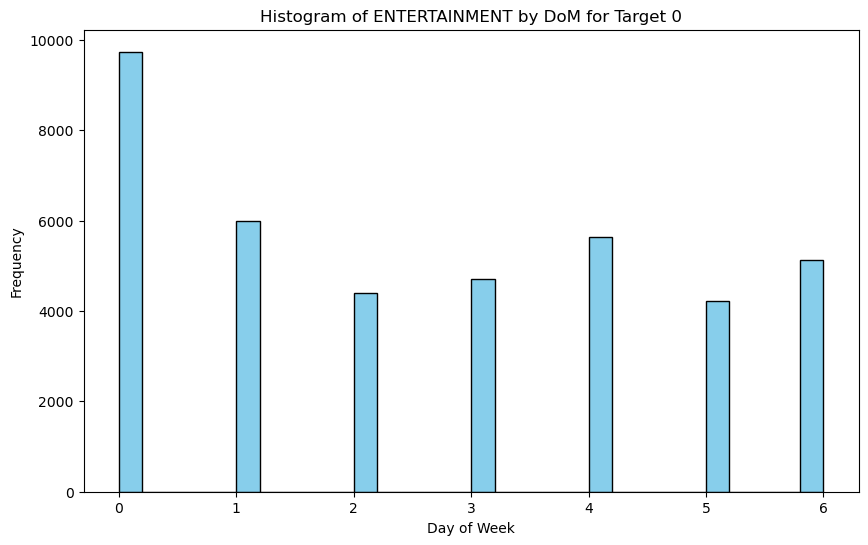

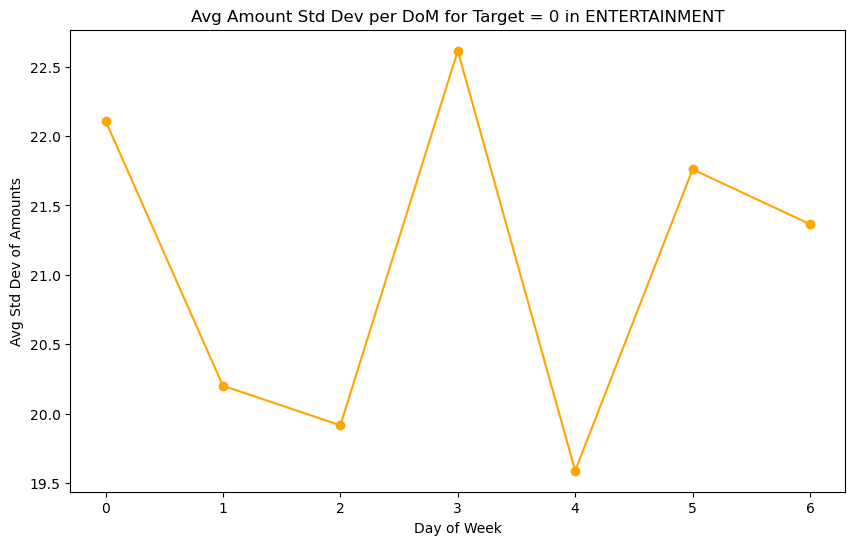

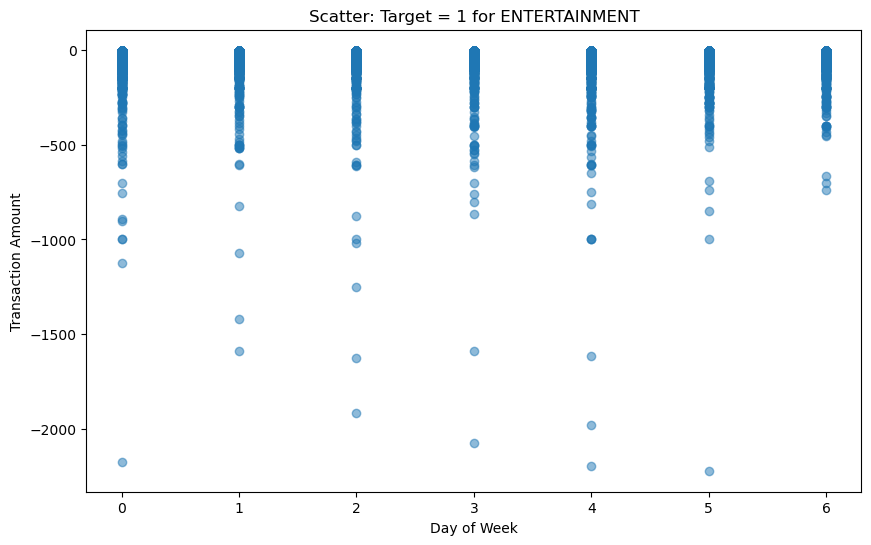

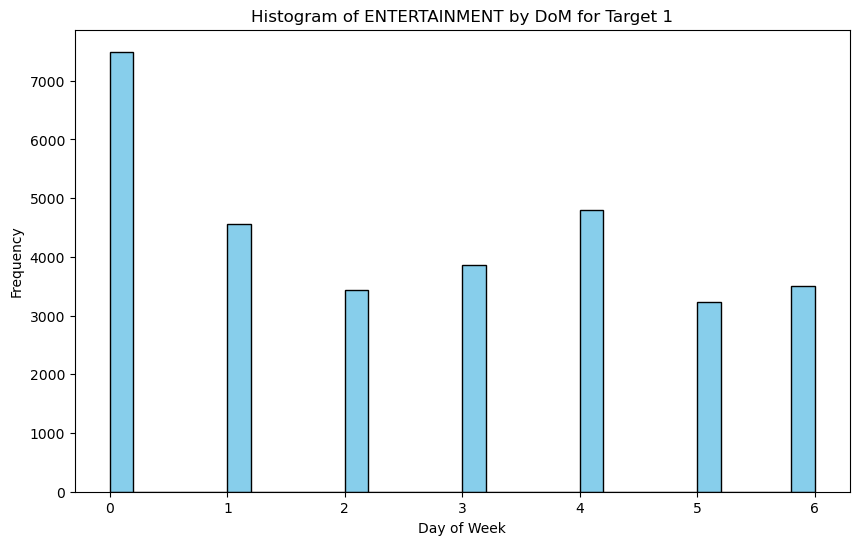

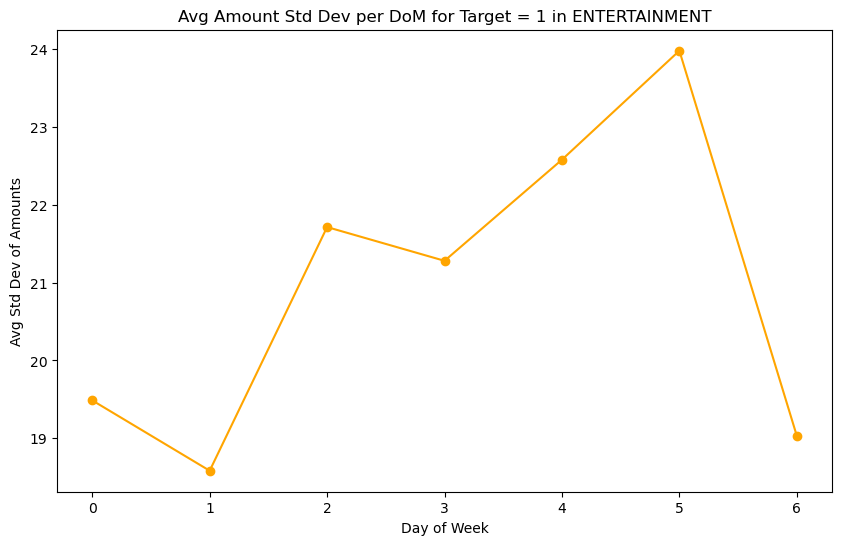

{0: day_type
0    22.110255
1    20.201031
2    19.915961
3    22.614622
4    19.588724
5    21.759994
6    21.365045
Name: std_amount, dtype: float64, 1: day_type
0    19.486593
1    18.582600
2    21.714104
3    21.280456
4    22.579982
5    23.980622
6    19.031377
Name: std_amount, dtype: float64}
{0: day_type
0   -27.951574
1   -27.867095
2   -31.471172
3   -35.817035
4   -28.316563
5   -28.136751
6   -29.176737
Name: avg_amount, dtype: float64, 1: day_type
0   -26.284854
1   -27.334238
2   -26.975303
3   -27.238800
4   -29.353397
5   -30.458496
6   -27.173054
Name: avg_amount, dtype: float64}


In [62]:
avg_std_by_day, avg_amt_by_day = plot_cat_week(cats_to_codes["ENTERTAINMENT"])
print(avg_std_by_day)
print(avg_amt_by_day)

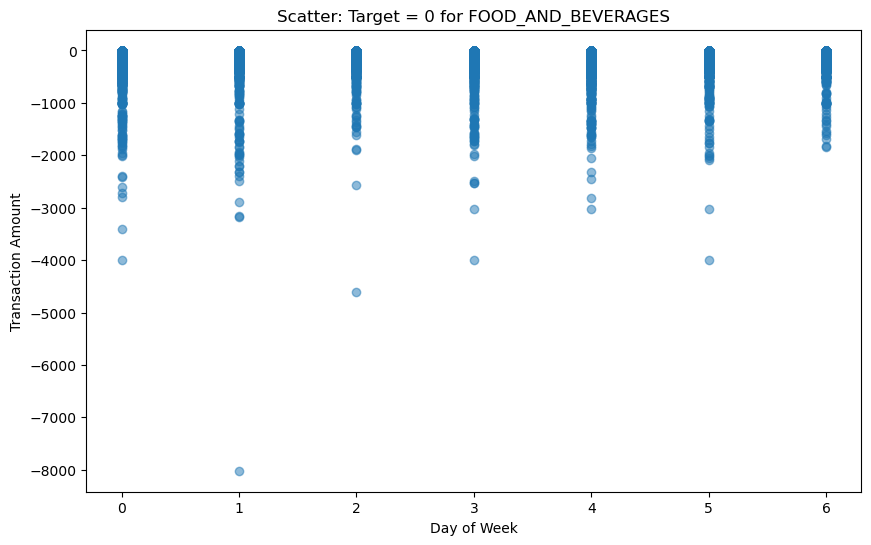

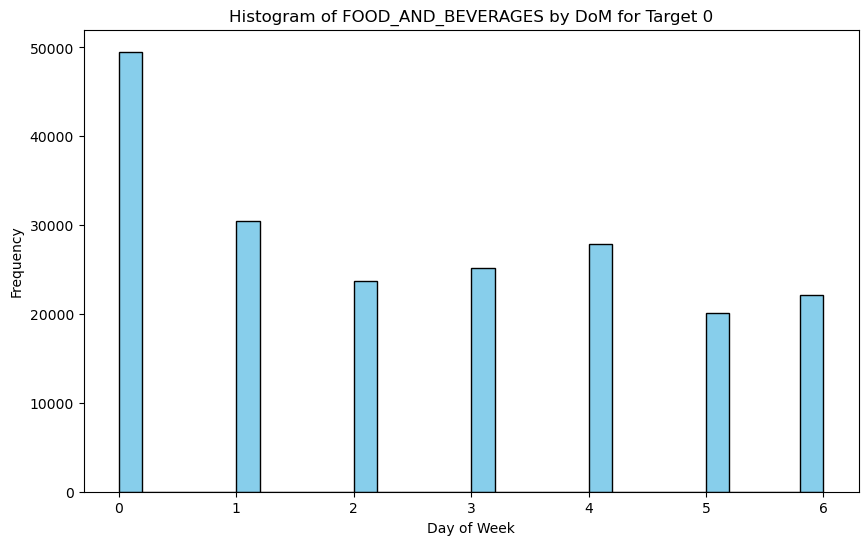

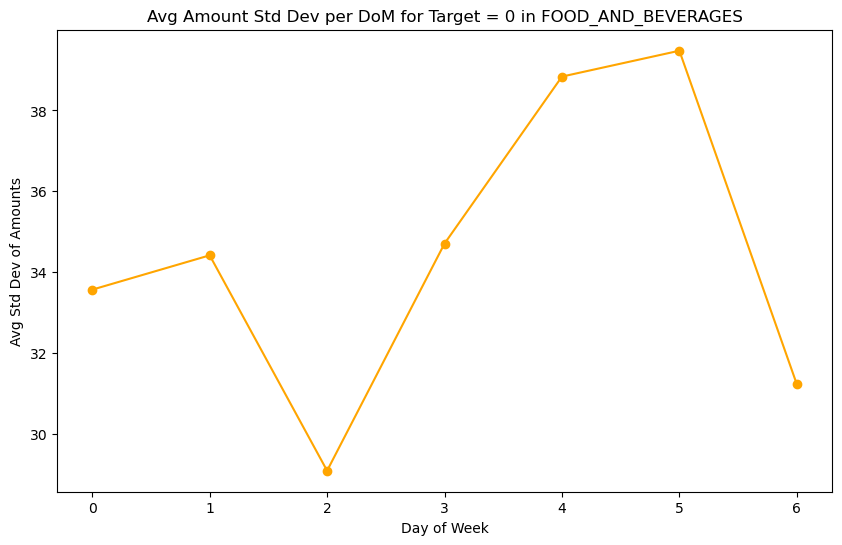

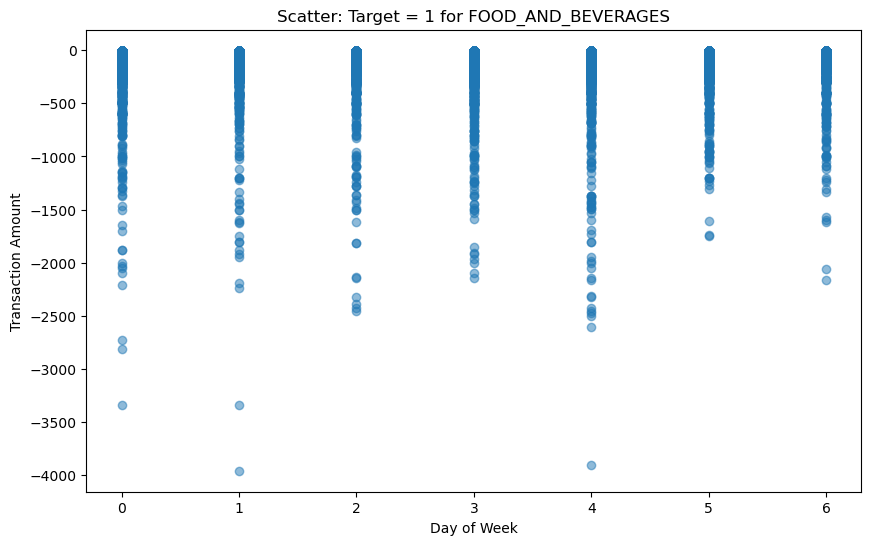

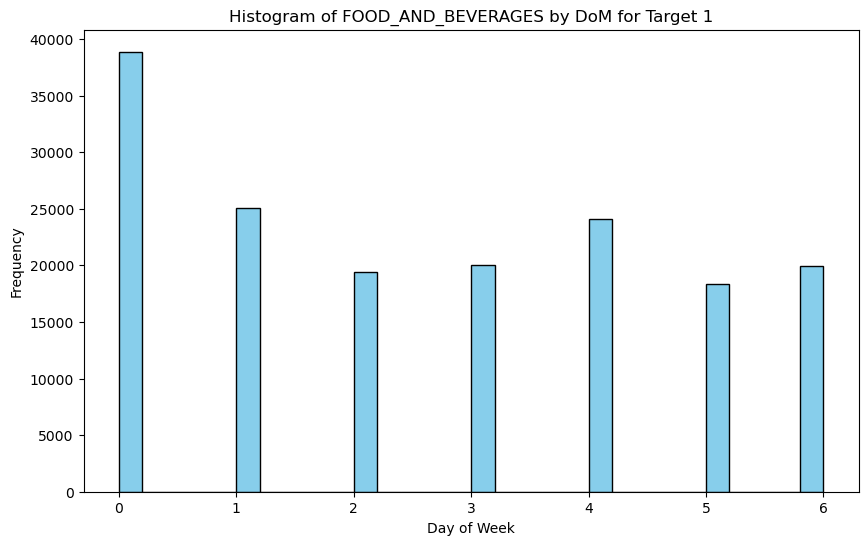

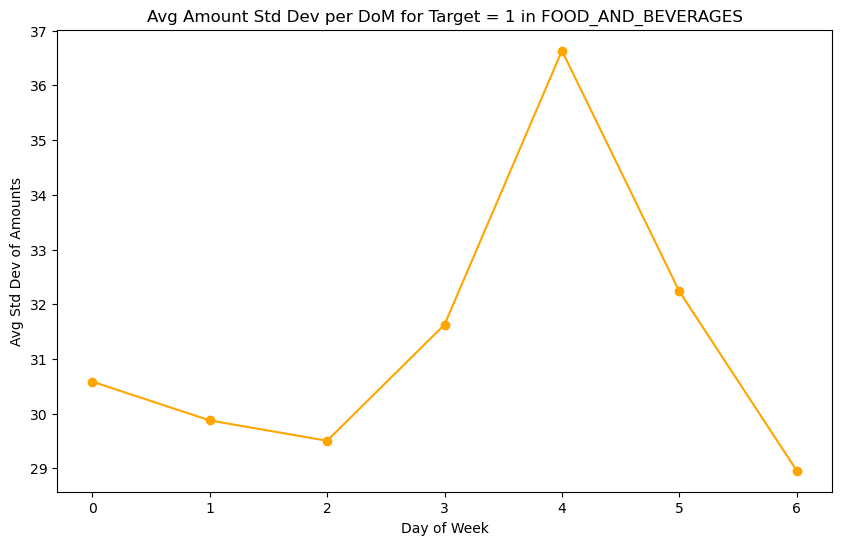

{0: day_type
0    33.570009
1    34.418599
2    29.092971
3    34.709513
4    38.838068
5    39.477722
6    31.232122
Name: std_amount, dtype: float64, 1: day_type
0    30.585474
1    29.876529
2    29.503804
3    31.627017
4    36.632953
5    32.232834
6    28.956899
Name: std_amount, dtype: float64}
{0: day_type
0   -31.631715
1   -31.381287
2   -29.086657
3   -34.322901
4   -34.931020
5   -35.204697
6   -31.326113
Name: avg_amount, dtype: float64, 1: day_type
0   -31.260648
1   -31.686886
2   -30.177478
3   -32.408053
4   -33.987907
5   -31.555758
6   -29.185969
Name: avg_amount, dtype: float64}


In [67]:
avg_std_by_day, avg_amt_by_day = plot_cat_week(cats_to_codes["FOOD_AND_BEVERAGES"])
print(avg_std_by_day)
print(avg_amt_by_day)

Features to consider

In [85]:
trans_cats

,code,description
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


In [76]:
monthly_cats = [0,1,2,3,4,5,10,12,13,7,8,19,17,26,29,31,32,33,34,35,36] #monthly seasonal
weekly_cats = [0,1,2,3,4,5,7,8,9,10,14,16,17,18,19,20,22,28,33,35] #weekly seasonal
blip_cats = [6,10,15,16,21,23,24,25,27,30] #sporadic and more likely to cause defaults